# 1) Packages Imports

In [1]:
import sys
import lib.dragon
sys.modules['dragon'] = sys.modules['lib.dragon']

In [2]:
import os
import sys
import importlib
import graphviz
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import openml

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from dragon.search_space.bricks_variables import mlp_var, identity_var, operations_var, mlp_const_var, dag_var, node_var, activation_var
from dragon.search_space.base_variables import CatVar, Constant, DynamicBlock, IntVar, FloatVar, ArrayVar, Variable
from dragon.search_space.dag_encoding import AdjMatrix, Node
from dragon.search_space.dag_variables import NodeVariable, HpVar
from dragon.search_operators.base_neighborhoods import ArrayInterval, DynamicBlockInterval, CatInterval, ConstantInterval
from dragon.search_operators.dag_neighborhoods import CatHpInterval, NodeInterval
from dragon.utils.plot_functions import draw_cell, load_archi, str_operations

from dragon.utils.plot_functions import expr_to_mini_dag, graph_to_formula

import numpy as np
from dragon.utils.plot_functions import graph_to_formula


# 2) Data

In [3]:
df = pd.read_csv(f"data/6000_points.csv")
df = df.drop(columns=['system:index', 'QA60', '.geo'])
df = df.drop(columns=['B8A'])
df = df.drop(columns=['date'])

### SAVI

In [4]:
df['SAVI'] = (df['B8']-df['B4'])/(df['B8']+df['B4']+0.5)*(1.5)

### NDVI

In [5]:
df['NDVI'] = (df['B8']-df['B4'])/(df['B8']+df['B4'])

### BSI

In [6]:
df['BSI'] = (df['B6'] + df['B4'] - df['B5'] - df['B2']) / (df['B6'] + df['B4'] + df['B5'] + df['B2'])

### Other test

In [7]:
df['TEST'] = 1/(df['B8']+df['B4'])

In [8]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,lat,lon,SAVI,NDVI,BSI,TEST
0,1380,3202,2266,1245,1101,1240,1413,1716,1944,1959,37.335014,-95.326731,0.337084,0.224758,0.053082,0.000313
1,1317,49,42,889,503,288,247,208,190,141,-21.011541,-124.765524,-0.513388,-0.342657,-0.392157,0.002331
2,1162,2031,1475,951,850,968,1036,1136,1265,1185,11.062935,-11.792313,0.151149,0.100790,0.028599,0.000464
3,1286,1291,444,980,823,532,832,1995,2736,2485,-1.910390,114.546423,0.970837,0.647332,0.164785,0.000331
4,1381,2050,1363,1126,1016,975,1155,1617,1845,1806,27.868199,120.743335,0.448139,0.298813,0.063821,0.000360


### Newton gravitational law in absolute value $F = \frac{G \, m_1 \, m_2}{r^2}$

In [9]:
n = 6000

# uniform in [1,10] for masses and distance
m1_exp = np.random.uniform(0, 15, size=n)
m2_exp = np.random.uniform(0, 15, size=n)
r_exp  = np.random.uniform(0, 10, size=n)

df = pd.DataFrame({"m1": 10**m1_exp, "m2": 10**m2_exp, "r": 10**r_exp})
df['NEWTON'] = (6.67430e-11 * df['m1'] * df['m2']) / df['r']**2
df.head()

,m1,m2,r,NEWTON
0,1.187087e+03,5.933691e+12,7.683816e+02,7.962682e-01
1,7.966825e+05,1.981238e+02,3.152760e+08,1.059854e-19
2,5.432458e+06,9.557871e+00,4.157245e+08,2.005174e-20
3,8.678512e+01,8.130486e+04,4.392174e+02,2.441229e-09
4,1.451495e+00,5.359753e+07,1.449542e+03,2.471181e-09


In [270]:
M = (np.random.rand(100) + 0.1) * 5*1e24
m = 100 * (np.random.rand(100) + 0.1) * 1e5
r = (np.random.rand(100) + 0.1) * 6500 * 1e3
G = 6.67430e-11

F = G * M * m / r**2
# F = M * m / r**2

df = pd.DataFrame({"M": M, "m": m, "r": r})
df['NEWTON'] = F
df.head()

,M,m,r,NEWTON
0,4.140968e+24,1.879015e+06,1.737895e+06,1.719454e+08
1,2.714177e+24,4.991119e+06,2.270455e+06,1.753945e+08
2,5.484757e+24,8.399754e+06,4.782522e+06,1.344360e+08
3,5.421813e+24,3.576981e+06,7.132060e+06,2.544702e+07
4,2.282692e+24,8.210354e+06,9.776894e+05,1.308619e+09


### X and z definition

In [271]:
output = 'NEWTON' # NDVI, SAVI, BSI, TEST, NEWTON
X = df.drop([output], axis=1)
z = df[[output]]

In [272]:
X.head()

,M,m,r
0,4.140968e+24,1.879015e+06,1.737895e+06
1,2.714177e+24,4.991119e+06,2.270455e+06
2,5.484757e+24,8.399754e+06,4.782522e+06
3,5.421813e+24,3.576981e+06,7.132060e+06
4,2.282692e+24,8.210354e+06,9.776894e+05


In [273]:
z.head()

,NEWTON
0,1.719454e+08
1,1.753945e+08
2,1.344360e+08
3,2.544702e+07
4,1.308619e+09


# 3) Feature Importance with XGBoost

Feature Importance Ranking:
  feature  importance
2       r    0.837643
1       m    0.126426
0       M    0.035931

Feature Scores Dictionary:
{'r': 0.837643027305603, 'm': 0.12642602622509003, 'M': 0.03593099117279053}


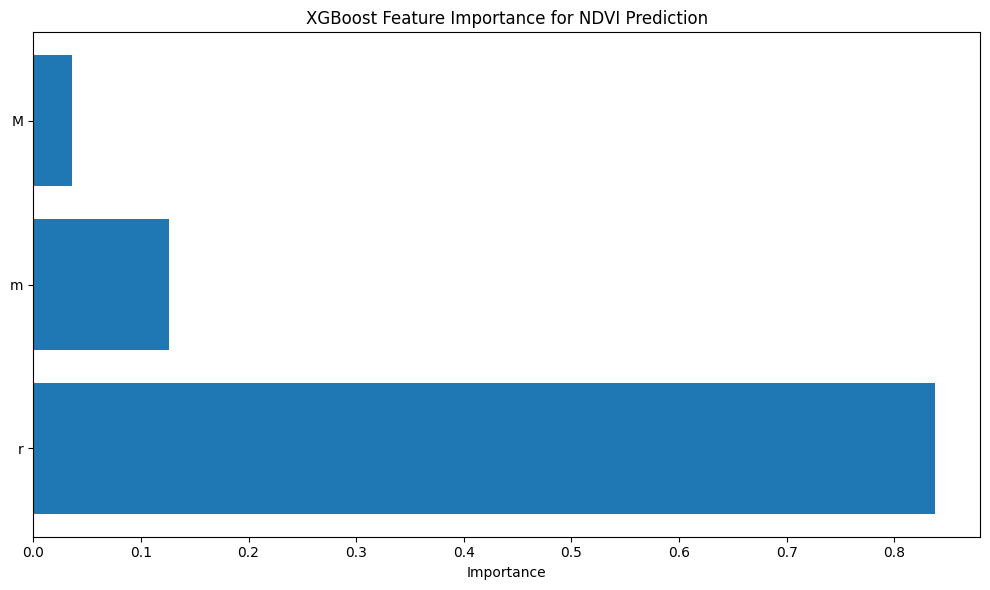


Top 10 features:
['r', 'm', 'M']

Shape of original features: (100, 3)
Shape of selected features: (100, 3)


In [274]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Normalize features for XGBoost
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train XGBoost model for feature importance
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_scaled, z.values.ravel())

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance Ranking:")
print(feature_importance)

# Create dictionary with performance scores for each feature
feature_scores_dict = dict(zip(feature_importance['feature'], feature_importance['importance']))
print("\nFeature Scores Dictionary:")
print(feature_scores_dict)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance for NDVI Prediction')
plt.tight_layout()
plt.show()

# Select top features (e.g., top 10)
top_n = 10
top_features = feature_importance.head(top_n)['feature'].tolist()
print(f"\nTop {top_n} features:")
print(top_features)

# Use selected features for your symbolic regression
X_selected = X[top_features]
print(f"\nShape of original features: {X.shape}")
print(f"Shape of selected features: {X_selected.shape}")

### Top x features selected

In [275]:
num_keep_features = X.shape[1]
top_features = feature_importance.head(num_keep_features)['feature'].tolist()
X.drop(columns=[col for col in X.columns if col not in top_features], inplace=True)

In [276]:
X.head()

,M,m,r
0,4.140968e+24,1.879015e+06,1.737895e+06
1,2.714177e+24,4.991119e+06,2.270455e+06
2,5.484757e+24,8.399754e+06,4.782522e+06
3,5.421813e+24,3.576981e+06,7.132060e+06
4,2.282692e+24,8.210354e+06,9.776894e+05


In [277]:
X.shape

(100, 3)

In [278]:
z.head()

,NEWTON
0,1.719454e+08
1,1.753945e+08
2,1.344360e+08
3,2.544702e+07
4,1.308619e+09


# 4) Meta Architecture

In [279]:
class MetaArchi(nn.Module):
    def __init__(self, args, input_shape):
        super().__init__()
        self.input_shape = input_shape
        assert isinstance(args['Dag'], AdjMatrix), f"The 'Dag' argument should be an 'AdjMatrix'. Got {type(args['Dag'])} instead."
        self.dag = args['Dag']
        self.dag.set(input_shape)


    def forward(self, X):
        return self.dag(X)
    def set_prediction_to_save(self, name, df):
        if hasattr(self, "prediction"):
            self.prediction[name] = df
        else:
            self.prediction = {name: df}
    def save(self, path):
        if not os.path.exists(path):
            os.makedirs(path)
        full_path = os.path.join(path, "best_model.pth")
        torch.save(self.state_dict(), full_path)
        if hasattr(self, "prediction"):
            for k in self.prediction.keys():
                self.prediction[k].to_csv(os.path.join(path, f"best_model_{k}_outputs.csv"))

In [280]:
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.FloatTensor(y.values)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_set = RegressionDataset(X, z)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

#### All possible combinations of feature indices for Select Features

In [281]:
from itertools import combinations

# Generate all possible combinations of feature indices
all_feature_combinations = []
num_features = X.shape[1] #12
for length in range(1, num_features):
    all_feature_combinations.extend([list(combo) for combo in combinations(range(num_features), length)])


In [282]:
all_feature_combinations

[[0], [1], [2], [0, 1], [0, 2], [1, 2]]

### Search space definition

In [336]:
from dragon.search_operators.base_neighborhoods import CatInterval, ConstantInterval, FloatInterval
from dragon.search_operators.dag_neighborhoods import EvoDagInterval, HpInterval
from dragon.search_space.base_variables import CatVar, Constant
from dragon.search_space.bricks.basics import Identity
from dragon.search_space.bricks.symbolic_regression import *
from dragon.search_space.dag_variables import EvoDagVariable, HpVar
from dragon.search_space.bricks_variables import (
    operations_var,
    dag_var,
)
from dragon.search_space.base_variables import ArrayVar
from dragon.search_space.dag_encoding import SymbolicNode
from dragon.search_operators.base_neighborhoods import ArrayInterval

# ── Feature importance → CatVar weights ──────────────────────────────
# Build a per-feature probability vector aligned with X.columns,
# then convert it into per-combination weights for the CatVar.
feature_names_list = X.columns.tolist()
num_feat = len(feature_names_list)
feature_probs = [feature_scores_dict.get(col, 1.0 / num_feat)
                 for col in feature_names_list]

combo_weights = SelectFeatures.combination_weights(
    feature_probs, all_feature_combinations
)

# ── Search-space variables ────────────────────────────────────────────
unary_var = HpVar(
    "UnaryOp",
    CatVar(
        "UnaryOpType",
        features=[Identity, Inverse, Negate],
        neighbor=CatInterval()
    ),
    hyperparameters={},
    neighbor=HpInterval()
)
select_features_var = HpVar(
    "SelectFeatures",
    Constant("SelectFeaturesOp", SelectFeatures, neighbor=ConstantInterval()),
    hyperparameters={
        "feature_indices": CatVar(
            "feature_indices",
            features=all_feature_combinations,
            weights=combo_weights,# biased by XGBoost importance
            neighbor=CatInterval()
        )
    },
    neighbor=HpInterval()
)
# power_features_var = HpVar(
#     "Power",
#     Constant("PowerOp", Power, neighbor=ConstantInterval()),
#     hyperparameters={
#         "exponent": FloatVar(
#             "exponent", lower=-3.0, upper=3.0, neighbor=FloatInterval(0.5)
#         )
#     },
#     neighbor=HpInterval()
# )
power_features_var = HpVar(
    "Power",
    Constant("PowerOp", Power, neighbor=ConstantInterval()),
    hyperparameters={
        "exponent": CatVar(
            "exponent",
            features=[-3, -2, -1, 1, 2, 3],
            neighbor=CatInterval()
        )
    },
    neighbor=HpInterval()
)


sum_var = HpVar(
    "Sum",
    Constant("SumOp", SumFeatures, neighbor=ConstantInterval()),
    hyperparameters={},
    neighbor=HpInterval()
)

const_var = HpVar(
    "Constant",
    Constant("ConstantOp", ConstantBrick, neighbor=ConstantInterval()),
    hyperparameters={},
    neighbor=HpInterval()
)


candidate_operations = operations_var(
    "CandidateOperations",
    size=8,
    candidates=[
        select_features_var,
        unary_var,
        power_features_var,
        # sum_var,
        # const_var
    ],
    combiner_features=['add', 'mul'],
    activations=Constant(
        "id",
        value=nn.Identity(),
        neighbor=ConstantInterval()
    ),
    node_type=SymbolicNode
)


dag = EvoDagVariable(
                    label="Dag",
                    operations = candidate_operations,
                    init_complexity=1,
                    neighbor=EvoDagInterval(nb_mutations=1)
                )


search_space = ArrayVar(dag, label="Search Space", neighbor=ArrayInterval())

# 5) LOSS

### LOSS 1: without constants optimization

#### Custom loss function: Correlation

In [337]:
def correl(pred, true):
    """Calculates the Pearson correlation coefficient"""
    # Convert to numpy if needed
    if isinstance(pred, torch.Tensor):
        pred = pred.numpy()
    if isinstance(true, torch.Tensor):
        true = true.numpy()
    
    # Calculate deviations from mean
    pred_dev = pred - pred.mean()
    true_dev = true - true.mean()
    
    # Calculate covariance
    cov = np.sum(pred_dev * true_dev)
    
    # Calculate standard deviations
    std_pred = np.sqrt(np.sum(pred_dev ** 2))
    std_true = np.sqrt(np.sum(true_dev ** 2))
    
    # Return correlation coefficient
    if std_pred == 0 or std_true == 0:
        return 0.0
    return cov / (std_pred * std_true + 1e-8)

#### Loss loop

In [338]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get feature names and number of features dynamically
feature_names = X.columns.tolist()
num_features = X.shape[1]

def eval(args, eps=1e-1, num_features=num_features):
    model = MetaArchi(args, input_shape=(num_features,)).to(device)
    
    # # Optimization
    # rand = np.random.rand()
    # if rand > 0.5:
    #     X_train_full, y_train_full = loader_to_tensors(train_loader, device)
    #     fit_constants_lbfgs(model, X_train_full, y_train_full, steps=50, lr=1.0)

    model.eval()

    all_pred, all_true = [], []

    with torch.no_grad():
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            all_pred.append(pred.detach().cpu())
            all_true.append(yb.detach().cpu())
    pred_all = torch.cat(all_pred)
    true_all = torch.cat(all_true)

    mse = np.inf
    selected_c = 0

    if len(pred_all.shape) > 1:
        for c in range(pred_all.shape[-1]):
            loss = 1 -(correl(pred_all[:, c:c+1], true_all))**2
            if loss < mse:
                mse = loss
                selected_c = c
        pred_all = pred_all[:, selected_c]

    pred_all = pred_all.squeeze().numpy()
    true_all = true_all.squeeze().numpy()

    # close_matches = np.sum(np.abs(pred_all - true_all) < eps)
    # fraction_close = close_matches / len(pred_all)
    # var = np.abs(true_all.std() - pred_all.std())
    return model, pred_all, true_all, mse
    

def loss_function(args, idx, eps=1e-1, mse_threshold=0.04, feature_names=feature_names, *kwargs):
    labels = [e.label for e in search_space]
    args = dict(zip(labels, args))

    model, y_pred, y_true, mse = eval(args, eps)

    # Formula extraction disabled to avoid slow sympy.simplify on complex expressions
    # try:
    #     expr = graph_to_formula(
    #         args['Dag'].matrix,
    #         np.asarray(feature_names),
    #         args['Dag'].operations
    #     )
    # except Exception as e:
    #     expr = None
    expr = None

    print(
        f"Idx={idx}, MSE = {mse:.10f}"
        # f"formula={expr}"
    )
    rand = np.random.rand()
    if rand > 0.5: # This is passed since there's no expression calculated
        if expr is not None:
            try:
                mini_dag = expr_to_mini_dag(expr, feature_names)
                args['Dag'] = mini_dag
                model, y_pred, y_true, mse= eval(args, eps)
                expr = graph_to_formula(
                    args['Dag'].matrix,
                    np.asarray(feature_names),
                    args['Dag'].operations
                )
                print(f"Idx={idx}, mini dag MSE={mse:.6f}, formula = {expr}")
            except Exception as e:
                pass
        model.mini_x = [v for v in args.values()]
    df = pd.DataFrame({
        "pred": y_pred,
        "true": y_true
    })
    model.set_prediction_to_save("prediction", df)
    return mse.item(), model


### LOSS 2: with constant optimization

#### Optimization of constants

In [339]:
# No constant optimization during search — the loss (1 - R²) is scale-invariant,
# so it can't distinguish C=1 from C=G. Constants are recovered in post-processing.
# This keeps each evaluation fast (single forward pass).

#### Loss loop

In [340]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_names = X.columns.tolist()
num_features = X.shape[1]


def eval(args, num_features=num_features):
    model = MetaArchi(args, input_shape=(num_features,)).to(device)
    model.eval()

    all_pred, all_true = [], []
    with torch.no_grad():
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            all_pred.append(pred.detach().cpu())
            all_true.append(yb.detach().cpu())
    pred_all = torch.cat(all_pred)
    true_all = torch.cat(all_true)

    mse = np.inf
    selected_c = 0
    if len(pred_all.shape) > 1:
        for c in range(pred_all.shape[-1]):
            loss = 1 - correl(pred_all[:, c:c+1], true_all) ** 2
            if loss < mse:
                mse, selected_c = loss, c
        pred_all = pred_all[:, selected_c]

    return model, pred_all.squeeze().numpy(), true_all.squeeze().numpy(), mse


def loss_function(args, idx, feature_names=feature_names, **kwargs):
    labels = [e.label for e in search_space]
    args = dict(zip(labels, args))

    model, y_pred, y_true, mse = eval(args)
    print(f"Idx={idx}, MSE = {mse:.10f}")

    model.mini_x = [v for v in args.values()]
    df = pd.DataFrame({"pred": y_pred, "true": y_true})
    model.set_prediction_to_save("prediction", df)
    return mse.item(), model

# 6) Search

In [341]:
from dragon.search_algorithm.mutant_ucb import Mutant_UCB
import shutil

for path in ["/save", "save"]:
    if os.path.isdir(path):
        shutil.rmtree(path)
        print(f"Deleted directory: {path}")


EXPLORATION_THRESHOLD = 1e-4  # switch from E=1000 → E=0.01
FINAL_THRESHOLD = 1e-5         # stop completely — formula found
T_MAX = 5000                   # max iterations per phase
K_INIT = 200
save_dir = "save/NDVI_formula/"

# Phase 1: Exploration (E=1000) until loss < EXPLORATION_THRESHOLD
print("=== Phase 1: Exploration (E=1000) ===")
search_algorithm = Mutant_UCB(
    search_space=search_space,
    evaluation=loss_function,
    T=T_MAX,
    K=K_INIT,
    N=1,
    E=1000,
    save_dir=save_dir,
    clean_all=False,
    verbose=True,
    loss_threshold=EXPLORATION_THRESHOLD,
)
search_algorithm.run()
print(f"[Exploration done] best loss = {search_algorithm.min_loss:.8f}")

if search_algorithm.min_loss >= EXPLORATION_THRESHOLD:
    print(f"Did not reach {EXPLORATION_THRESHOLD} after {T_MAX} iters. Stopping.")
else:
    # Phase 2: Exploitation (E=0.01) until loss < FINAL_THRESHOLD
    pop_size = len(pd.read_csv(os.path.join(save_dir, "computation_file.csv")))
    T_exploit = pop_size + T_MAX
    print(f"\n=== Phase 2: Exploitation (E=0.01, {T_MAX} new iters) ===")
    search_algorithm = Mutant_UCB(
        search_space=search_space,
        evaluation=loss_function,
        T=T_exploit,
        K=K_INIT,
        N=1,
        E=0.01,
        save_dir=save_dir,
        clean_all=False,
        verbose=True,
        pop_path=save_dir,
        loss_threshold=FINAL_THRESHOLD,
    )
    search_algorithm.run()
    best = search_algorithm.min_loss
    if best <= FINAL_THRESHOLD:
        print(f"\nFormula found! Final loss = {best:.10f}")
    else:
        print(f"\nExploitation done. Best loss = {best:.8f} (threshold {FINAL_THRESHOLD} not reached)")

Deleted directory: save
=== Phase 1: Exploration (E=1000) ===
2026-03-03 13:32:57,164 | WARNING | Use multiple processes if you want to use the distributed version.
2026-03-03 13:32:57,293 | INFO | The whole population has been created (size = 200), 200 have been randomy initialized.
Idx=0, MSE = 0.9591898918
2026-03-03 13:32:57,300 | INFO | Best found! 0.9591898918151855 < inf
Idx=1, MSE = 0.7265031338
2026-03-03 13:32:57,306 | INFO | Best found! 0.7265031337738037 < 0.9591898918151855
Idx=2, MSE = 0.7265031338
Idx=3, MSE = 1.0000000000
2026-03-03 13:32:57,316 | ERROR | Worker with individual 3 failed with 'float' object has no attribute 'item', set loss to inf
Traceback (most recent call last):
  File "/Users/elyaschikhaoui/Desktop/dragon/DRAGON/lib/dragon/search_algorithm/search_algorithm.py", line 324, in evaluate
    loss = timed_evaluation(x, idx, self.time_max*60, self.evaluation)
  File "/Users/elyaschikhaoui/Desktop/dragon/DRAGON/lib/dragon/search_algorithm/search_algorithm.py

# 7) Post - Processing

## Alignment

In [37]:
from dragon.utils.plot_functions import graph_to_all_formulas

# Load the best model
best_model_params = load_archi("save/NDVI_formula/best_model/x.pkl")
labels = [e.label for e in search_space]
best_model_dict = dict(zip(labels, best_model_params))
m_dag = best_model_dict['Dag'].matrix
n_dag = str_operations(best_model_dict["Dag"].operations)

# ─── Step 1: Run the model and find the best output channel ──────────────────
feature_names_list = X.columns.tolist()
num_feat = len(feature_names_list)

model = MetaArchi(best_model_dict, input_shape=(num_feat,)).to(device)
model.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)
        all_pred.append(pred.detach().cpu())
        all_true.append(yb.detach().cpu())

pred_all = torch.cat(all_pred)
true_all = torch.cat(all_true)

selected_c = 0
best_loss = np.inf
if len(pred_all.shape) > 1:
    for c in range(pred_all.shape[-1]):
        loss = 1 - (correl(pred_all[:, c:c+1], true_all))**2
        if loss < best_loss:
            best_loss = loss
            selected_c = c
    pred_all = pred_all[:, selected_c]

pred_all = pred_all.squeeze().numpy().astype(np.float64)
true_all = true_all.squeeze().numpy().astype(np.float64)
print(f"Selected output channel: {selected_c}  (loss = {best_loss:.8f})")

# ─── Step 2: Extract the formula for the SELECTED channel ────────────────────
try:
    all_formulas = graph_to_all_formulas(
        best_model_dict['Dag'].matrix,
        np.asarray(feature_names_list),
        best_model_dict['Dag'].operations
    )
    print(f"\nAll output-channel formulas ({len(all_formulas)} channels):")
    for i, f_expr in enumerate(all_formulas):
        marker = " <<< SELECTED" if i == selected_c else ""
        print(f"  [{i}]: {f_expr}{marker}")

    original_expr = all_formulas[selected_c]
    print(f"\nSelected formula: {original_expr}")
except Exception as e:
    original_expr = None
    all_formulas = []
    print(f"Error extracting formulas: {e}")

# ─── Step 3: Post-processing alignment (float64 to avoid overflow) ───────────
A = np.column_stack([pred_all, np.ones_like(pred_all)])
coeffs, _, _, _ = np.linalg.lstsq(A, true_all, rcond=None)
a1, a0 = coeffs
pred_aligned = a1 * pred_all + a0
mse_final = np.mean((pred_aligned - true_all)**2)
print(f"\nPost-processing alignment: a1={a1:.6e}, a0={a0:.6e}, MSE={mse_final:.6e}")

# ─── Step 4: Final formula ───────────────────────────────────────────────────
if original_expr is not None:
    final_formula = f"{a1:.6e} * ({original_expr}) + {a0:.6e}"
    print(f"\nFINAL ALIGNED FORMULA: {final_formula}")

Selected output channel: 2  (loss = 0.00000000)

All output-channel formulas (3 channels):
  [0]: M
  [1]: M*m/(M + 2*m)**3
  [2]: M*m/(125*r**2) <<< SELECTED

Selected formula: M*m/(125*r**2)

Post-processing alignment: a1=8.342875e-09, a0=2.810666e-26, MSE=2.592157e+03

FINAL ALIGNED FORMULA: 8.342875e-09 * (M*m/(125*r**2)) + 2.810666e-26


In [343]:
best_model_params = load_archi("save/NDVI_formula/best_model/x.pkl")
labels = [e.label for e in search_space]
best_model_dict = dict(zip(labels, best_model_params))
m_dag = best_model_dict['Dag'].matrix
n_dag = str_operations(best_model_dict["Dag"].operations)

In [344]:
best_model_dict

{'Dag': ModuleList(
   (0): 
   (input shape) (np.int64(3),) -- (combiner) add -- (op) Identity() -- (activation) Identity() -- (output shape) (3,)
   (1): 
   (input shape) (1,) -- (combiner) mul -- (op) SelectFeatures(feature_indices=[1, 2]) -- (activation) Identity() -- (output shape) (1,)
   (2): 
   (input shape) (1,) -- (combiner) add -- (op) Constant(value=1.0000) -- (activation) Identity() -- (output shape) (1,)
   (3): 
   (input shape) (1,) -- (combiner) add -- (op) SelectFeatures(feature_indices=[0, 1]) -- (activation) Identity() -- (output shape) (1,)
   (4): 
   (input shape) (1,) -- (combiner) add -- (op) Inverse() -- (activation) Identity() -- (output shape) (1,)
   (5): 
   (input shape) (1,) -- (combiner) mul -- (op) SelectFeatures(feature_indices=[0, 2]) -- (activation) Identity() -- (output shape) (1,)
   (6): 
   (input shape) (1,) -- (combiner) mul -- (op) Negate() -- (activation) Identity() -- (output shape) (1,)
   (7): 
   (input shape) (1,) -- (combiner) mul --

## Graph representation

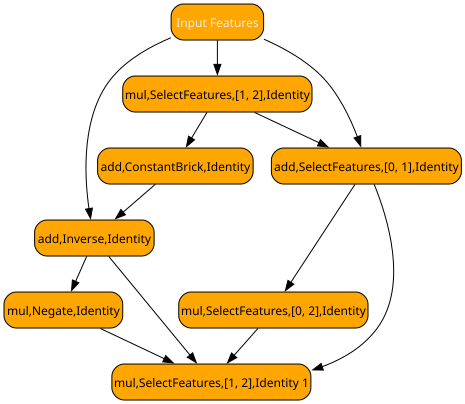

In [345]:
from IPython.display import display
import shutil
import importlib
import os

# Ensure notebook kernel can see Homebrew-installed binaries (macOS)
homebrew_dot = '/opt/homebrew/bin'
if homebrew_dot not in os.environ.get('PATH', ''):
    os.environ['PATH'] = os.environ.get('PATH', '') + ':' + homebrew_dot

# Optional graphviz: only use if the system 'dot' binary is available
_graphviz = None
try:
    if shutil.which("dot") is not None:
        _graphviz = importlib.import_module('graphviz')
except Exception:
    _graphviz = None


def _draw_with_networkx(adj_matrix, node_descriptions):
    """Fallback drawer using networkx + matplotlib (no system `dot` required)."""
    try:
        import networkx as nx
        import matplotlib.pyplot as plt
    except Exception as e:
        raise RuntimeError("networkx or matplotlib not available") from e

    G_nx = nx.DiGraph()
    for i, nd in enumerate(node_descriptions):
        G_nx.add_node(i, label=nd)
    for i in range(adj_matrix.shape[0]):
        for j in range(adj_matrix.shape[1]):
            if adj_matrix[i, j]:
                G_nx.add_edge(i, j)

    pos = nx.spring_layout(G_nx, seed=0)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, max(4, len(node_descriptions) * 0.25)))
    nx.draw_networkx_nodes(G_nx, pos, node_color='#ffa600', node_size=1100)
    nx.draw_networkx_edges(G_nx, pos, arrows=True, arrowstyle='->', arrowsize=12)
    labels = {i: f"[{i}] {nd}" for i, nd in enumerate(node_descriptions)}
    nx.draw_networkx_labels(G_nx, pos, labels=labels, font_size=8)
    plt.axis('off')
    return plt.gcf()


def print_dag_text(adj_matrix, node_descriptions, show_matrix=False):
    """Print a compact, easy-to-read textual representation of the DAG.

    Shows for each node: index, children list, parents list, and the node description.
    """
    import textwrap
    n = adj_matrix.shape[0]

    parents = [[str(j) for j in range(n) if adj_matrix[j, i]] for i in range(n)]
    children = [[str(j) for j in range(n) if adj_matrix[i, j]] for i in range(n)]

    # build rows
    rows = []
    for i in range(n):
        desc = node_descriptions[i]
        # ensure compact string
        desc_s = textwrap.shorten(str(desc), width=60, placeholder='...')
        p = ','.join(parents[i]) if parents[i] else '-'
        c = ','.join(children[i]) if children[i] else '-'
        rows.append((i, c, p, desc_s))

    # column widths
    idx_w = max(3, max(len(str(r[0])) for r in rows) + 2)
    child_w = max(8, max(len(r[1]) for r in rows) + 2)
    parent_w = max(8, max(len(r[2]) for r in rows) + 2)
    desc_w = max(20, max(len(r[3]) for r in rows) + 2)

    # header
    header = f"{'Idx'.ljust(idx_w)}| {'Children'.ljust(child_w)}| {'Parents'.ljust(parent_w)}| Description"
    sep = '-' * (len(header) + 10)
    print(sep)
    print(header)
    print(sep)
    for i, c, p, desc in rows:
        print(f"[{str(i).rjust(idx_w-2)}] | {c.ljust(child_w)} | {p.ljust(parent_w)} | {desc}")
    print(sep)

    if show_matrix:
        print("Adjacency matrix:")
        print(adj_matrix)


def show_dag_graph(adj_matrix=None, node_descriptions=None, dag=None,
                   name_input="Input Features", color_input=None,
                   output_name="dag_viz", fmt="png", show_node_table=True,
                   prefer_text=False):
    """Display a DAG (reusable).

    Provide either:
      - dag (object with .matrix and .operations), or
      - both adj_matrix (np.ndarray) and node_descriptions (list from `str_operations`).

    Behavior:
      - Uses Graphviz if the `dot` binary is available and `prefer_text` is False.
      - Otherwise prints a clean textual DAG and uses NetworkX fallback for a simple visual if available.
    """
    if dag is not None:
        adj_matrix = dag.matrix
        node_descriptions = str_operations(dag.operations)

    if adj_matrix is None or node_descriptions is None:
        raise ValueError("Provide either `dag` or both `adj_matrix` and `node_descriptions`.")

    # If user explicitly prefers text, just print text and return
    if prefer_text:
        print_dag_text(adj_matrix, node_descriptions)
        return None

    dot_available = (_graphviz is not None)

    if dot_available:
        G = _graphviz.Digraph(output_name, format=fmt,
                              node_attr={'nodesep': '0.02', 'shape': 'box', 'rankstep': '0.02',
                                         'fontsize': '12', 'fontname': 'sans-serif'})
        # draw_cell expects: (graph, nodes, matrix, color, list_nodes, name_input=None, color_input=None)
        G, _ = draw_cell(G, node_descriptions, adj_matrix, "#ffa600", [], name_input=name_input, color_input=color_input)
        try:
            display(G)
        except Exception as e:
            print("Graphviz rendering failed — falling back to NetworkX drawing:", e)
            try:
                fig = _draw_with_networkx(adj_matrix, node_descriptions)
                display(fig)
            except Exception as e2:
                print("NetworkX fallback failed:", e2)
                dot_available = False

    if not dot_available:
        # Print textual representation first (clearest)
        print("\n--- Textual DAG view (clean) ---\n")
        print_dag_text(adj_matrix, node_descriptions)
        # Then try a simple visual fallback
        try:
            fig = _draw_with_networkx(adj_matrix, node_descriptions)
            display(fig)
        except Exception:
            # ignore: user requested text primarily
            pass

    return None


# Example usage (existing notebook variables):
# For a purely textual view: show_dag_graph(adj_matrix=m_dag, node_descriptions=n_dag, prefer_text=True)
# Default: will try graphviz then fall back to text+simple visual
show_dag_graph(adj_matrix=m_dag, node_descriptions=n_dag, name_input="Input Features")


# 8) Comments and further improvement

Random forest faire de l'importance features, tester sans l'importance selection pour NDVI, récupérer les formules du papier pysr pour faire les tests

on évalue deux graphes pour voir si c'est les mêmes sur la poplation initiale, on continue de tirer des randoms tant qu'ya pas de solutioins K_init*0.7 différents (dans Mutant_ECB on stocke)
mpi4py pour paralléliser

AdamW pour l'optim, sur Dragon tutorials teaching tp boucle d'entrainement pytorch

Et si on faisait une step d'optimisation des constantes mais seulement après ? On optimise les 1 par exemple pour obtenir des constantes.

XGBOOST qui donne un score pour ensuite le feed à selectfeatures, librairie XGboost ou sklearn
random forrest regression (devient non linéaire)
selection n features
si on arrive à chaque fois à l'avoir avec K, T, E différents
srun -u 
regarder le nombre d'itérations que pysr prend (100 par défaut)

Prendre une uniforme d'exponentielle avec r entre 10**u u uniforme entre 0 et 10 et m de la forme 10 **v et v entre 0 et 15
tester si pysr trouve rapidement
Try with the benchmark
Decomposition en elements simple, pius ensuite on weight numeratuer et denominateur A/B devient (aA+b)/(cB+d)
Add the pytorch loop

See if I do this up there it has impact

Tableau de comparaison en document pour savoir le runtime la convergence, la loss pour pouvoir se comparer

turn on and off the new features that I implement